# Homework 1

### Deadline: Monday 24 March 2024 (by 19h00)

### Credits: 20 points

### Instructions:

- When you finish, please submit a single **.ipynb** file via email to wbanda@yachaytech.edu.ec


- The homework is **individual**. Please include your name in the notebook.


- Within a **single python notebook**, solve the following problems.

# Name: Mariannly Marquez

## 1. Population dynamics (8 points)

The system of ordinary differential equations (ODEs) describing the population dynamics of two prey species ($x$ and $y$) and one predator species ($z$) is given by:

$$
\begin{aligned}
\frac{dx}{dt} &= g_1\,x \left( 1 - \frac{x}{c_1} \right) - p_1\,x\,z, \\
\frac{dy}{dt} &= g_2\,y \left( 1 - \frac{y}{c_2} \right) - p_2\,y\,z, \\
\frac{dz}{dt} &= e_1\,p_1\,x\,z + e_2\,p_2\,y\,z - d\,z.
\end{aligned}
$$

where:

- $g_1$, $g_2$ are the intrinsic growth rates (e.g. birth rates) of the prey populations,

- $c_1$, $c_2$ are the carrying capacities of the prey populations (the carrying capacity of an environment is the maximum population size of a biological species that can be sustained by that specific environment),
  
- $p_1$, $p_2$ are the predation rates of the predator on each prey (e.g. how successful a hunt is),

- $e_1$, $e_2$ are the conversion efficiencies of consumed prey into predator biomass (the conversion efficiency tells us how efficiently a predator can use the energy from its prey to reproduce),

- $d$ is the natural death rate of the predator. Note that the death rates of the two prey species are intrinsically given by their individual carrying capacities.

This system models the interactions where both prey species grow logistically but are consumed by a common predator.

### State vector and slope:

**(a)** Write down this system of ODEs in terms of the system state vector $S(t)$, i.e. $\frac{dS}{dt} = F(S)$. Identify the slope function $F(S)$ and indicate whether or not it can be explicitly written as a function of $S$. Create a python function for the slope $F(S)$.


We define $S(t)$,

$$
S(t)=\left[\begin{array}{l}
x(t) \\
y(t) \\
z(t)
\end{array}\right]
$$

Then, the system is

$$
\frac{d S(t)}{d t}=\left[\begin{array}{l}
\frac{d x}{d t} \\
\frac{d y}{d t} \\
\frac{d z}{d t}
\end{array}\right]=\left[\begin{array}{l}
g_1 x\left(1-\frac{x}{c_1}\right)-p_1 x z \\
g_2 y\left(1-\frac{y}{c_2}\right)-p_2 y z \\
e_1 p_1 x z+e_2 p_2 y z-d z
\end{array}\right] \\
$$

Then, we can simplify a bit

$$
\frac{d S(t)}{d t} = \left[\begin{array}{ccc}
g_1\left(1-\frac{x}{c_1}\right)-p_1 z & 0 & 0 \\
0 & g_2\left(1-\frac{y}{c_2}\right)-p_2 z & 0 \\
0 & 0 & e_1 p_1 x+e_2 p_2 y-d
\end{array}\right] S(t)

$$

$$
\frac{d S(t)}{d t} = \left[\begin{array}{ccc}
g_1\left(1-\frac{S_1(t)}{c_1}\right)-p_1 S_3(t) & 0 & 0 \\
0 & g_2\left(1-\frac{S_2(t)}{c_2}\right)-p_2 S_3(t) & 0 \\
0 & 0 & e_1 p_1 S_1(t)+e_2 p_2 S_2(t)-d
\end{array}\right] S(t) 
$$

Thus, we have found the slope function written explicitly in $S(t)$ and its components. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def population_dynamic(t, s, dict_params): #t is not in use, maybe remove it
    """
    ODEs describing the population dynamics of two prey species x, y and one predator species z.
    
        input:
    t: time
    s: state variables [x, y, z]
    dict_params: dictionary containing the parameters of the model
        g1: growth rate of prey species x
        g2: growth rate of prey species y
        c1: carrying capacity of prey species x
        c2: carrying capacity of prey species y
        p1: predation rate of prey species x
        p2: predation rate of prey species y
        e1: conversion efficiency of prey species x
        e2: conversion efficiency of prey species y
        d: death rate of predator species z

        output:
    s_prime: time derivative of the state variables
    
    """

    # Extracting the parameters from the dictionary
    g1 = dict_params['g1']
    g2 = dict_params['g2']
    c1 = dict_params['c1']
    c2 = dict_params['c2']
    p1 = dict_params['p1']
    p2 = dict_params['p2']
    e1 = dict_params['e1']
    e2 = dict_params['e2']
    d = dict_params['d']
    
    # Defining the diagonal elements of the matrix
    a_11 = g1 * (1 - s[0]/c1) - p1 * s[2]
    a_22 = g2 * (1 - s[1]/c2) - p2 * s[2]
    a_33 = e1 * p1 * s[0] + e2 * p2 * s[1] - d

    # Defing the ODE system
    s_prime = np.dot(np.array([[a_11, 0, 0], [0, a_22, 0], [0, 0, a_33]]), s)

    return s_prime


### ODE integration methods:

**(b)** Create a python function that implements a trapezoidal Euler method for ODE integration.


In [3]:
def trapezoidal_method(f, t, s0, dict_params, dt):
    """
    Numerical integration of the ODEs using the trapezoidal method.
    
        input:
    f: function describing the ODEs
    t: time
    s: state variables
    dict_params: dictionary containing the parameters of the model
    dt: time step
    
        output:
    s: integrated state variables
    
    """

    s = np.zeros([len(t),3])
    s[0] = s0

    # Loop
    for i in range(0, len(t) - 1):

        # Frist approximation of the state variables at the next time step
        s[i+1] = s[i] + dt * f(t[i], s[i], dict_params)

        # Correcting the approximation with trapezoidal method
        s[i+1] = s[i] + 0.5 * dt * (f(t[i], s[i], dict_params) + f(t[i+1], s[i+1], dict_params))

    return s


**(c)** Design your own third-order RK method (RK3), and create a python function for this integrator.


A third order Runge-Kutta method for solving first-order ordinary differential equations of the form

$$
S^{\prime}(x)=F(t, S(t))
$$

is given by

$$
S_{n+1}=S_n+\sum_{i=1}^3 b_i k_i
$$

where, for $1 \leq i \leq 3$,

$$
k_i=h F\left(t_n+c_i h, S_n+\sum_{j=1}^3 a_{i, j} k_j\right)
$$

Generally, Runge Kutta methods can be described using Butcher tables od the form

\begin{array}{c|cccc}
c_1 & a_{1,1} & a_{1,2} & \ldots & a_{1, s} \\
c_2 & a_{2,1} & a_{2,2} & \ldots & a_{2, s} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
c_s & a_{s, 1} & a_{s, 2} & \ldots & a_{s, s} \\
\hline & b_1 & b_2 & \ldots & b_s
\end{array}

In this case, $s=3$ and the Butcher table is

\begin{array}{c|ccc}
0 & 0 & 0 & 0 \\
\alpha & \alpha & 0 & 0 \\
\beta & \frac{\beta}{\alpha}\frac{\beta-3\alpha(1-\alpha)}{(3\alpha-2)} & -\frac{\beta}{\alpha}\frac{\beta-\alpha}{(3\alpha-2)} & 0 \\
\hline
& 1-\frac{3\alpha+3\beta-2}{6\alpha\beta} & \frac{3\beta-2}{6\alpha(\beta-\alpha)} & \frac{2-3\alpha}{6\beta(\beta-\alpha)}
\end{array}

where $\alpha$ and $\beta$ are free parameters with $\alpha \neq 0$, $\alpha \neq 2/3$, $\beta \neq 0$, and $\alpha \neq \beta$. We can choose $\alpha=1/2$ and $\beta=1$ so that,

\begin{array}{c|ccc}
0 & 0 & 0 & 0 \\
1/2 & 1/2 & 0 & 0 \\
1 & -1 & 2 & 0 \\
\hline
 & 1/6 & 2/3 & 1/6
\end{array}


References:


Butcher, John. (1997). Numerical Methods for Differential Equations and Applications. http://www.math.auckland.ac.nz/Research/Reports/view.php?id=370.

Wikipedia contributors. (2025, March 10). List of Runge–Kutta methods. In Wikipedia, The Free Encyclopedia. Retrieved March 22, 2025, from https://en.wikipedia.org/w/index.php?title=List_of_Runge%E2%80%93Kutta_methods&oldid=1279696139



In [4]:
def rk3_method(f, t, s0, dict_params, dt):
    """
    Numerical integration of the ODEs using the Runge-Kutta 3rd order method.
    
        input:
    f: function describing the ODEs
    t: time
    s: state variables
    dict_params: dictionary containing the parameters of the model

        output:
    s: integrated state variables
    
    """

    s = np.zeros([len(t), 3])
    s[0] = s0

    # Loop
    for i in range(0, len(t) - 1):
        # First slope
        k1 = f(t[i], s[i], dict_params)

        # Second slope
        k2 = f(t[i] + 0.5 * dt, s[i] + 0.5 * dt * k1, dict_params)

        # Third slope
        k3 = f(t[i] + dt, s[i] - dt * k1 + 2 * dt * k2, dict_params)

        # Updating the state variables
        s[i+1] = s[i] + dt * (k1 + 4 * k2 + k3) / 6

    return s


**(d)** Write a python function for the **Butcher's Runge-Kutta method**, which is a popular method for integrating ODEs with a high order of accuracy. It is obtained by following a similar approach to the one we discussed in class. This method uses six points $k_1, k_2, k_3$, $k_4$, $k_5$, and $k_6$. A weighted average of these points is used to produce the approximation of the solution. The algorithm relies on computing the following slopes:

$$
k_1  =  F(t_j,S(t_j))\\
k_2  =  F\left(t_j+\frac{h}{4},S(t_j)+\frac{1}{4}k_1h\right)\\
k_3  =  F\left(t_j+\frac{h}{4},S(t_j)+\frac{1}{8}k_1h+\frac{1}{8}k_2h\right)\\
k_4  =  F\left(t_j+\frac{h}{2},S(t_j)-\frac{1}{2}k_2h+k_3h\right)\\
k_5  =  F\left(t_j+\frac{3h}{4},S(t_j)+\frac{3}{16}k_1h+\frac{9}{16}k_4h\right)\\
k_6  =  F\left(t_j+h,S(t_j)-\frac{3}{7}k_1h+\frac{2}{7}k_2h+\frac{12}{7}k_3h-\frac{12}{7}k_4h+\frac{8}{7}k_5h\right)
$$

The solution is then constructed with the step size ($h$, same as `dt`)as follows:

$$
S(t_{j+1}) = S(t_j) + \frac{h}{90}\left(7k_1 + 32k_3 + 12k_4 + 32k_5+7k_6\right).
$$


In [5]:
def butcher_rk_method(f, t, s0, dict_params, dt):
    """
    Numerical integration of the ODEs using the Butcher's Runge-Kutta method.
    
        input:
    f: function describing the ODEs
    t: time
    s: state variables
    dict_params: dictionary containing the parameters of the model
    dt: time step
    
        output:
    s: integrated state variables
    
    """

    s = np.zeros([len(t), 3])
    s[0] = s0

    # Loop
    for i in range(0, len(t) - 1):
        # First slope
        k1 = f(t[i], s[i], dict_params)

        # Second slope
        k2 = f(t[i] + dt/4, s[i] + dt/4 * k1, dict_params)

        # Third slope
        k3 = f(t[i] + dt/4, s[i] + dt/8 * k1 + dt/8 * k2, dict_params)

        # Fourth slope
        k4 = f(t[i] + dt/2, s[i] - dt/2 * k2 + dt * k3, dict_params)

        # Fifth slope
        k5 = f(t[i] + 3 * dt/4, s[i] + 3 * dt/16 * k1 + 9 * dt/16 * k4, dict_params)

        # Sixth slope
        k6 = f(t[i] + dt, s[i] - 3 * dt/7 * k1 + 2 * dt/7 * k2 + 12 * dt/7 * k3 - 12 * dt/7 * k4 + 8 * dt/7 * k5, dict_params)

        # Updating the state variables
        s[i+1] = s[i] + dt * (7 * k1 + 32 * k3 + 12 * k4 + 32 * k5 + 7 * k6) / 90

    return s



### Settings and initial conditions:

**(e)** Create a dictionary that allocates all the user-defined initial conditions needed for integration, including an option for the user to select the integration method. The default parameters in the dictionary should be:

| Parameter | Value | Description |
|---|---|---|
| `g1` | 1.0 | Growth rate of prey 1 |
| `c1` | 200.0 | Carrying capacity of prey 1 |
| `p1` | 0.01 | Predation rate of predator on prey 1 |
| `g2` | 1.2 | Growth rate of prey 2 |
| `c2` | 150.0 | Carrying capacity of prey 2 |
| `p2` | 0.008 | Predation rate of predator on prey 2 |
| `e1` | 0.08 | Conversion efficiency of prey 1 to predator |
| `e2` | 0.07 | Conversion efficiency of prey 2 to predator |
| `d` | 0.15 | Death rate of predator |
| `x0` | 100.0 | Initial population of prey 1 |
| `y0` | 80.0 | Initial population of prey 2 |
| `z0` | 20.0 | Initial population of predator |
| `t_span` | (0, 200) | Time span for simulation |
| `dt` | 0.01 | Time step size ($=h$) |
| `method` | RK3 | Integration method |



In [6]:
dict_params = {'g1': 1, 'g2': 1.2, 'c1': 200, 'c2': 150, 'p1': 0.01, \
    'p2': 0.008, 'e1': 0.08, 'e2': 0.07, 'd': 0.15, 'x0': 100, 'y0': 80, \
    'z0': 20, 't_span': [0, 200], 'dt': 0.01, 'method': 'RK3'}



### Time stepping:

**(f)** Create a python function that integrates the system of ODEs using the settings and initial conditions as arguments. The function should perform integration for all three methods (according to the option `method`) and return the resulting times ($t$) and system states $S(t)$ as arrays.


In [7]:
def main(dict_params):
    """
    Main function.
    
        input:
    dict_params: dictionary containing the parameters of the model

        output:
    t: time
    s: integrated state variables
    
    """

    # Time
    dt = dict_params['dt']
    t = np.arange(dict_params['t_span'][0], dict_params['t_span'][1], dt)

    # Initial state variables
    s0 = np.array([dict_params['x0'], dict_params['y0'], dict_params['z0']])

    # Numerical integration
    if dict_params['method'] == 'Trapezoidal':
        s = trapezoidal_method(population_dynamic, t, s0, dict_params, dt)
    elif dict_params['method'] == 'RK3':
        s = rk3_method(population_dynamic, t, s0, dict_params, dt)
    elif dict_params['method'] == 'ButcherRK':
        s = butcher_rk_method(population_dynamic, t, s0, dict_params, dt)

    return t, s


### Plotting function:

**(g)** Create a python function that takes the times ($t$) and system states $S(t)$ as arguments and returns a 3-panel figure showing the evolution of each species ($x$, $y$, and $z$) in the system as a function of time, $t$.


In [8]:
def plot_results(t, s):
    """
    Plot the results.
    
        input:
    t: time
    s: state variables

        output:
    Plot
    
    """

    # Plot
    fig, ax = plt.subplots(1, 3, figsize=(12,4), sharey=True, gridspec_kw={'wspace': 0.05})

    ax[0].plot(t, s[:, 0], label='Prey species x', color='purple')
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel('Population')
    ax[0].legend()

    ax[1].plot(t, s[:, 1], label='Prey species y', color='g')
    ax[1].set_xlabel('Time')
    ax[1].legend()

    ax[2].plot(t, s[:, 2], label='Predator species z', color='r')
    ax[2].set_xlabel('Time')
    ax[2].legend()

    plt.suptitle(f'Population Dynamics of Two Prey Species and One Predator Species - {dict_params["method"]} method')

    plt.show()


### Simulation:

**(h)** Call your time-stepping and plotting functions to run and display the results of three simulations (one per integration method), using the default settings and initial conditions from the table in (e). Based on your simulations, does the system reach equilibrium?

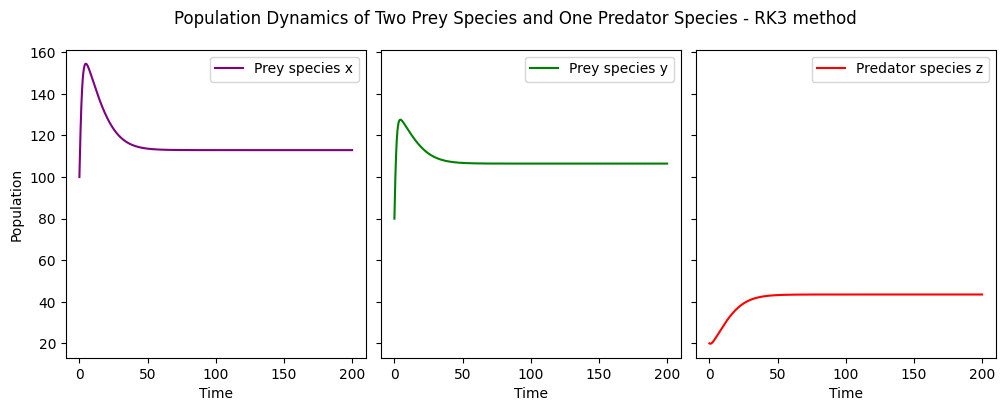

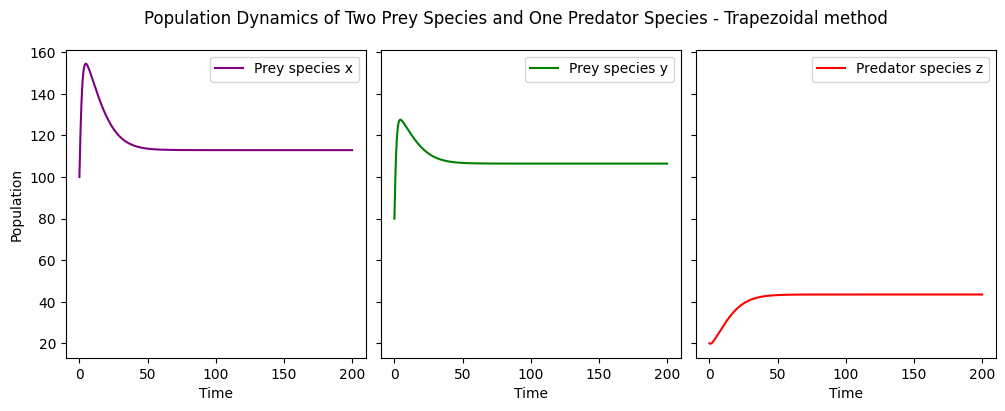

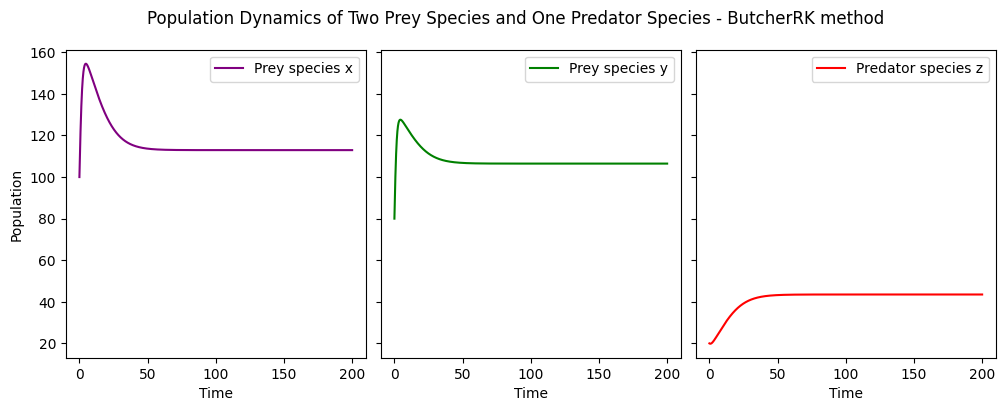

In [9]:
# Calling the main function for RK3 method
dict_params['method'] = 'RK3'
t, s_rk3 = main(dict_params)
plot_results(t, s_rk3)

# Calling the main function for Trapezoidal method
dict_params['method'] = 'Trapezoidal'
_, s_trap = main(dict_params)
plot_results(t, s_trap)

# Calling the main function for Butcher's RK method
dict_params['method'] = 'ButcherRK'
_, s_butcher = main(dict_params)
plot_results(t, s_butcher)

Based on my simulations, the system reach equilibrium fairly quickly. 

## 2. Dynamical systems and equilibrium (5 points)

### Python class:

**(a)** Reorganise all your code from problem 1 into a single python class that contains attributes and methods. The settings and initial conditions should be attributes and all the python functions should become methods. Add a method to compute $L_2$-norm errors.


In [10]:
from scipy.integrate import solve_ivp

In [52]:
class Population:
    """
    Class to describe the population dynamics of two prey species x, y and one predator species z.
    
    """

    def __init__(self, dict_params):
        """
        Constructor.
        
            input:
        dict_params: dictionary containing the parameters of the model
        
        """

        # Atributtes

        # Parameters
        self.g1 = dict_params['g1']
        self.g2 = dict_params['g2']
        self.c1 = dict_params['c1']
        self.c2 = dict_params['c2']
        self.p1 = dict_params['p1']
        self.p2 = dict_params['p2']
        self.e1 = dict_params['e1']
        self.e2 = dict_params['e2']
        self.d = dict_params['d']

        # Initial conditions
        self.s0 = np.array([dict_params['x0'], dict_params['y0'], dict_params['z0']])
            
        # Time 
        self.t_span = dict_params['t_span']
        self.t = np.arange(self.t_span[0], self.t_span[1], dict_params['dt'])
        self.dt = dict_params['dt']

        # State variables initialization
        self.s = np.zeros([len(self.t), 3])

        # Method
        self.method = dict_params['method']

    def population_dynamic(self, t, s):
        """
        ODEs describing the population dynamics of two prey species x, y and one predator species z.
        
            input:
        self: class object 

            output:
        s_prime: time derivative of the state variables
        
        """

        # Defining the diagonal elements of the matrix
        a_11 = self.g1 * (1 - s[0]/self.c1) - self.p1 * s[2]
        a_22 = self.g2 * (1 - s[1]/self.c2) - self.p2 * s[2]
        a_33 = self.e1 * self.p1 * s[0] + self.e2 * self.p2 * s[1] - self.d

        # Defing the ODE system
        s_prime = np.dot(np.array([[a_11, 0, 0], [0, a_22, 0], [0, 0, a_33]]), s)

        return s_prime

    def trapezoidal_method(self):
        """
        Numerical integration of the ODEs using the trapezoidal method.
        
            input:
        self: class object

            output:
        s: integrated state variables
        
        """

        self.s[0] = self.s0

        # Loop
        for i in range(0, len(self.t) - 1):

            # Frist approximation of the state variables at the next time step
            self.s[i+1] = self.s[i] + self.dt * self.population_dynamic(self.t, self.s[i])

            # Correcting the approximation with trapezoidal method
            self.s[i+1] = self.s[i] + 0.5 * self.dt * (self.population_dynamic(self.t, self.s[i]) + self.population_dynamic(self.t, self.s[i+1]))

        return self.s

    def rk3_method(self):
        """
        Numerical integration of the ODEs using the Runge-Kutta 3rd order method.
        
            input:
        self: class object
        
            output:
        s: integrated state variables
        
        """

        self.s[0] = self.s0

        # Loop
        for i in range(0, len(self.t) - 1):
            # First slope
            k1 = self.population_dynamic(self.t, self.s[i])

            # Second slope
            k2 = self.population_dynamic(self.t, self.s[i] + 0.5 * self.dt * k1)

            # Third slope
            k3 = self.population_dynamic(self.t, self.s[i] - self.dt * k1 + 2 * self.dt * k2)

            # Updating the state variables
            self.s[i+1] = self.s[i] + self.dt * (k1 + 4 * k2 + k3) / 6

        return self.s

    def butcher_rk_method(self):
        """
        Numerical integration of the ODEs using the Butcher's Runge-Kutta
        method.
        
            input:
        self: class object
        
            output:
        s: integrated state variables
        
        """
        
        self.s[0] = self.s0

        # Loop
        for i in range(0, len(self.t) - 1):
            # First slope
            k1 = self.population_dynamic(self.t, self.s[i])

            # Second slope
            k2 = self.population_dynamic(self.t, self.s[i] + self.dt/4 * k1)

            # Third slope
            k3 = self.population_dynamic(self.t, self.s[i] + self.dt/8 * k1 + self.dt/8 * k2)

            # Fourth slope
            k4 = self.population_dynamic(self.t, self.s[i] - self.dt/2 * k2 + self.dt * k3)

            # Fifth slope
            k5 = self.population_dynamic(self.t, self.s[i] + 3 * self.dt/16 * k1 + 9 * self.dt/16 * k4)

            # Sixth slope
            k6 = self.population_dynamic(self.t, self.s[i] - 3 * self.dt/7 * k1 + 2 * self.dt/7 * k2 + 12 * self.dt/7 * k3 - 12 * self.dt/7 * k4 + 8 * self.dt/7 * k5)

            # Updating the state variables
            self.s[i+1] = self.s[i] + self.dt * (7 * k1 + 32 * k3 + 12 * k4 + 32 * k5 + 7 * k6) / 90

        return self.s

    def integrate_main(self):
        """
        Main function.
        
            input:
        self: class object

            output:
        t: time
        s: integrated state variables
        
        """

        # Numerical integration
        if self.method == 'Trapezoidal':
            s = self.trapezoidal_method()
        elif self.method == 'RK3':
            s = self.rk3_method()
        elif self.method == 'ButcherRK':
            s = self.butcher_rk_method()

        self.s = s

        return self.t, self.s

    def get_reference_solution(self):
        """
        Generate reference solution using scipy.integrate.solve_ivp and RK45.
        
            input:
        self: class object

            output:
        s: integrated state variable (callable)
        """

        # Modifying the ODEs to be compatible with solve_ivp
        system = lambda t, s: self.population_dynamic(t, s)
        
        # Solve with high accuracy using RK45
        solution = solve_ivp(
            system,
            t_span=self.t_span,
            y0=self.s0,
            method='RK45',
            rtol=1e-13, 
            atol=1e-13,
            dense_output=True,  # Enable interpoation
            max_step=self.dt # its having trouble with the step size
        )
        
        # Create lambda function to return interpolated solution
        s_reference = lambda t: solution.sol(t).T if not np.isscalar(t) else solution.sol(t)
            
        return s_reference
            

    def l2_norm_error(self):
        """ 
        Compute the L2 norm between a reference state variable calculated with
        scipy.integrate.solve_ivp using RK45 and a given state vector.
        
            input:
        self: class object
        
            output:
        L2 norm
        """

        # Computing the L2 norm
        l2_norm = np.linalg.norm(self.s - self.get_reference_solution()(self.t))

        return l2_norm



    def plot_results(self):
        """
        Plot the results.
        
            input:
        self: class object

            output:
        Plot
        
        """

        # Plot
        fig, ax = plt.subplots(1, 3, figsize=(12,4), sharey=True, gridspec_kw={'wspace': 0.05})

        ax[0].plot(self.t, self.s[:, 0], label='Prey species x', color='purple')
        ax[0].set_xlabel('Time')
        ax[0].set_ylabel('Population')
        ax[0].legend()

        ax[1].plot(self.t, self.s[:, 1], label='Prey species y', color='g')
        ax[1].set_xlabel('Time')
        ax[1].legend()

        ax[2].plot(self.t, self.s[:, 2], label='Predator species z', color='r')
        ax[2].set_xlabel('Time')
        ax[2].legend()

        plt.suptitle(f'Population Dynamics of Two Prey Species and One Predator Species - {self.method} method')

        plt.show()


### Error analysis:

**(b)** Call the methods from your python class above to run $15$ simulations ($5$ simulations per integration method) for $5$ decreasing values of the time step size, `dt` (i.e. $h$). Then, compute the $L_2$-norm errors for all these $15$ runs and report the results in a single figure with the $L_2$-norm errors in the Y axis and $h$ in the X axis. Which method produces the most accurate results?


In [58]:
dt_list = [1, 0.5, 0.1, 0.05, 0.01]
method_list = ['Trapezoidal', 'RK3', 'ButcherRK']

# empty dict to store the L2 norm error for each simulation
l2_norm_dict = {}

In [59]:
# Two for loops to iterate over the method_list and dt_list
for method in method_list:

    # Updating the dictionary in method
    dict_params['method'] = method

    l2_norm_dict[method] = []
    
    for dt in dt_list:

        # Updating the dictionary in dt
        dict_params['dt'] = dt

        # Creating the object
        pop = Population(dict_params)

        # Integrating the ODEs
        t, s = pop.integrate_main()

        # Computing L2 norm error and saving
        l2_norm = pop.l2_norm_error()
        l2_norm_dict[method].append(l2_norm)

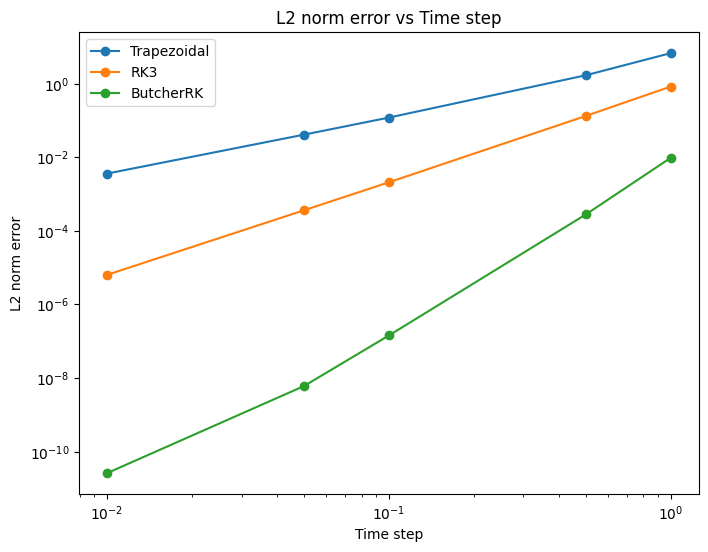

In [60]:
#Plotting the L2 norm error

fig, ax = plt.subplots(1, 1, figsize=(8,6))
ax.plot(dt_list, l2_norm_dict['Trapezoidal'], label='Trapezoidal', marker='o')
ax.plot(dt_list, l2_norm_dict['RK3'], label='RK3', marker='o')
ax.plot(dt_list, l2_norm_dict['ButcherRK'], label='ButcherRK', marker='o')

ax.set_xlabel('Time step')
ax.set_ylabel('L2 norm error')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('L2 norm error vs Time step')
ax.legend()
plt.show()

In [61]:
# Computing the slopes of error plot in log scale
log_dt = np.log10(dt_list)
log_error_trap = np.log10(l2_norm_dict['Trapezoidal'])
log_error_rk3 = np.log10(l2_norm_dict['RK3'])
log_error_butcher = np.log10(l2_norm_dict['ButcherRK'])


# Fit line to log-log data
order_trap, _ = np.polyfit(log_dt, log_error_trap, 1)
order_rk3, _ = np.polyfit(log_dt, log_error_rk3, 1)
order_butcher, _ = np.polyfit(log_dt, log_error_butcher, 1)

print(f'Trapezoidal method: {order_trap}')
print(f'RK3 method: {order_rk3}')
print(f'ButcherRK method: {order_butcher}')

Trapezoidal method: 1.6255442002327936
RK3 method: 2.555562047863049
ButcherRK method: 4.331425389258474


We have that the butchers method produces the most accurate results, followed by the RK3 method and the trapezoidal method in last place.

We get the order of the error by fitting a line to the log-log error curves and computing the slope. We found that the Butcher's method has an order of 4.3, the closest from the expected order of 4. The RK3 method has an order of 2.6 which is shows good convergence but not quite reaching the theoretical value of 3.0. And the trapezoidal method has an order of 1.6, which is reasonably close to the theoretical value of 2.0 as well.

I believe that my reference solution using scipy with RK45 is not accurate enough and might be close to the order of magnitude of the Butcher's method. This affects the order of convergence of all methods.


**(d)** After computing equilibrium solutions for multiple values of the predator mortality $d$, you should create a high-quality figure of the equilibrium populations of $x$, $y$, and $z$ (on the Y axis) versus $d$ (on the x-axis), and label what happens in the parameter regions outside of equilibrium conditions.


In [71]:
import sympy as sp

In [ ]:
# Adding methods to the class
class Population(Population):  # Inherits from existing Population class

    # Computing equilibrium points    
    def find_equilibrium(self):
        """
        Find analytical equilibrium points using SymPy
        
            input:
        self: class object

            output:
        list of physical equilibrium points
        """
        
        # Define symbolic variables
        x, y, z = sp.symbols('x y z')
        
        # Define the system of equations at equilibrium (set derivatives to 0)
        eq1 = x * (self.g1 * (1 - x/self.c1) - self.p1 * z)
        eq2 = y * (self.g2 * (1 - y/self.c2) - self.p2 * z)
        eq3 = z * (self.e1 * self.p1 * x + self.e2 * self.p2 * y - self.d)
        
        # Find equilibrium points by solving the system
        equilibria = sp.solve([eq1, eq2, eq3], [x, y, z])
        
        # Convert to numerical values. This is not working!!! need to filter 
        for sol in equilibria:
            x_val = float(sol[0].evalf())
            y_val = float(sol[1].evalf())
            z_val = float(sol[2].evalf())
        
            if x_val >= 0 and y_val >= 0 and z_val >= 0: #maybe need more filtering  but what?
                eq_points = np.array([(float(sol[0].evalf()), float(sol[1].evalf()), float(sol[2].evalf())) for sol in equilibria])

        return eq_points

In [94]:
# Computing equilibrium points for different d values

d_list = np.linspace(0.1, 1.0, 50)
equilibrium_points = []

for d in d_list:

    # Update the dictionary
    dict_params['d'] = d

    # Create a new object
    pop = Population(dict_params)
    # Find equilibrium points and save them
    eq_points = pop.find_equilibrium()
    equilibrium_points.append(eq_points)

In [ ]:
equilibrium_points.shape # why?? too many

(3, 7, 50)

ValueError: x and y must have same first dimension, but have shapes (50,) and (7, 50)

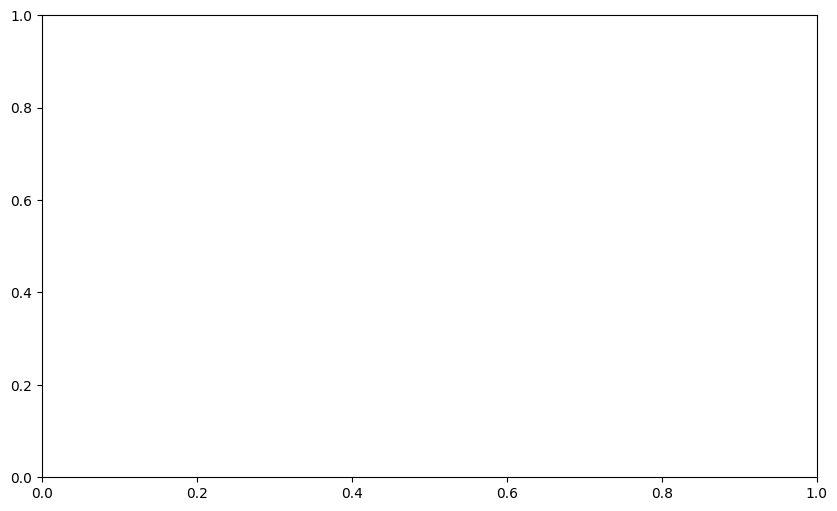

In [ ]:
# Plotting the bifurcation diagram
plt.figure(figsize=(10,6))

equilibrium_points = np.array(equilibrium_points).T
plt.plot(d_list, equilibrium_points[0], label='Prey x')
plt.plot(d_list, equilibrium_points[1], label='Prey y')
plt.plot(d_list, equilibrium_points[2], label='Predator z')

plt.xlabel('Predator mortality rate (d)')
plt.ylabel('Population at equilibrium')
plt.legend()
plt.grid(True)

plt.show()


**(e)** Based on your analysis, for what range of $d$ values the system reaches equilibrium? What happens outside of that range? Call your class again to run and compare equilibrium versus extinction scenarios using $3$ different values of $d$.


## 3. Quantum Harmonic Oscillator (7 points)

The Schrödinger equation for the quantum harmonic oscillator is:

$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2}+\frac{1}{2}m\omega^2x^2\psi=E\psi$$

It can be rewritten, in terms of a new variable, $\xi\equiv\sqrt{\frac{m\,\omega}{\hbar}}x$, as follows:

$$\frac{d^2\psi}{d\xi^2}=\left(\xi^2 -K\right)\psi$$

where $K\equiv\frac{2E}{\hbar\omega}$ is the energy in units of $\frac{1}{2}\hbar\omega$.

### Order reduction and slope function:

**(a)** Reduce the above ODE to first order. Write down the resulting slope function.



We define $S$,

$$
S(\xi)=\left[\begin{array}{c}
\psi \\
\frac{d \psi}{d \xi}
\end{array}\right]=\left[\begin{array}{l}
S_1(\xi) \\
S_2(\xi)
\end{array}\right]
$$

Such that

$$

\frac{d S(\xi)}{d \xi}= \left[\begin{array}{c}
\frac{d \psi}{d \xi} \\
\frac{d^2 \psi}{d \xi^2}
\end{array}\right]=\left[\begin{array}{c}
\frac{d \psi}{d \xi} \\
\left(\xi^2-K\right) \psi
\end{array}\right]=\left[\begin{array}{c}
S_2(\xi) \\
\left(\xi^2-K\right) S_1(\xi)
\end{array}\right]
$$

Then, the resulting slope function is

$$
\frac{d S(\xi)}{d \xi}= \left[\begin{array}{cc}
0 & 1 \\
\xi^2-K & 0
\end{array}\right] S(\xi)
$$


### Shooting method class:

**(b)** Carefully read the tasks (c-g) below and design a suitable python class with attributes and methods that solves the above ODE using **the shooting method** with the slope computed in (a). You may use scipy integrators; there is no need to design your own integrators in this problem.


In [98]:
import scipy.optimize as opt

In [ ]:
class harmonic_oscillator:
    """
    Harmonic oscillator class.
    
    """

    def __init__(self):
        """
        Constructor.
        
        """

        # Boundary conditions:
        self.psi_0 = 1
        self.psi_0_prime = 0

        # xi domain
        self.xi_i = -3
        self.xi_f = 3
        self.xi_axis = np.linspace(self.xi_i, self.xi_f, 101)


    # k values around k state (K=1,3,5,7,9,...)
    def k_values(self, k):
        return np.linspace(k - 0.5, k + 0.5, 21)
    
    # Wave function (Slope)
    def wave_function(self, xi, s, k):
        return np.dot(np.array([[0, 1], [xi**2 - k, 0]]), s)
    
    # Objective function
    def obj_function(self, psi_guess, k):

        diff_list = []
        
        # Iterate in k
        for ks in self.k_values(k):
            
            #writting the wave function for solve_ivp
            func = lambda xi, s, k: self.wave_function(xi, s, k)

            # Solution with this guess and k
            sol = solve_ivp(func, [self.xi_i, self.xi_f], np.asarray([self.psi_0, psi_guess], dtype = object),\
                            method='RK45', t_eval = self.xi_axis, args = (ks,))
            
            # Extract S1 solution at 0 (in the middle of the domain)
            psi_0_prime_num = sol.y[1][int(len(self.xi_axis)/2)]
            
            # Calculate the difference
            diff = psi_0_prime_num - self.psi_0_prime

            # Append to the list
            diff_list.append(diff)

        # Get the smallest difference
        min_diff = np.min(np.abs(diff_list))
        # Index of the smallest difference i.e the k value that minimizes the difference
        min_index = np.argmin(np.abs(diff_list))
        # print
        #print('Min diff:', min_diff, 'Min index:', min_index)
        
        self.min_k = self.k_values(k)[min_index]        

        return min_diff
    
    def optimize(self, psi_guess, k):
        """
        Optimize the objective function.
        
        """
        
        obj_func = lambda psi_guess: self.obj_function(psi_guess, k)

        # Optimization
        result = opt.fsolve(obj_func, psi_guess)
        

        # Solution with this optimized result
        func = lambda xi, s, k: self.wave_function(xi, s, k)

        sol = solve_ivp(func, [self.xi_i, self.xi_f], np.asarray([self.psi_0, result], dtype = object),\
                    method='RK45', t_eval = self.xi_axis, args = (self.min_k,))
        
        return sol
    
    def plot_results(self, sol):

        plt.figure(figsize=(10,6))

        plt.plot(sol.t, sol.y[0], label = 'Numerical Solution')

        plt.xlabel(r'$\xi$')
        plt.ylabel(r'$\psi$')

        plt.title('Harmonic Oscillator (K = {})'.format(self.min_k))
        plt.grid()
        plt.legend()
        plt.show()



### Tasks to be performed by your python class:

**(c)** Find the **ground state energy** of the harmonic oscillator, to six significant digits, by using **the shooting method**. That is, solve the above equation numerically, varying $K$ until you get a wave function that goes to zero at large $\xi$. The appropriate boundary conditions for the ground state (and any even state) are $\psi(0) = 1$, $\psi'(0) = 0$.


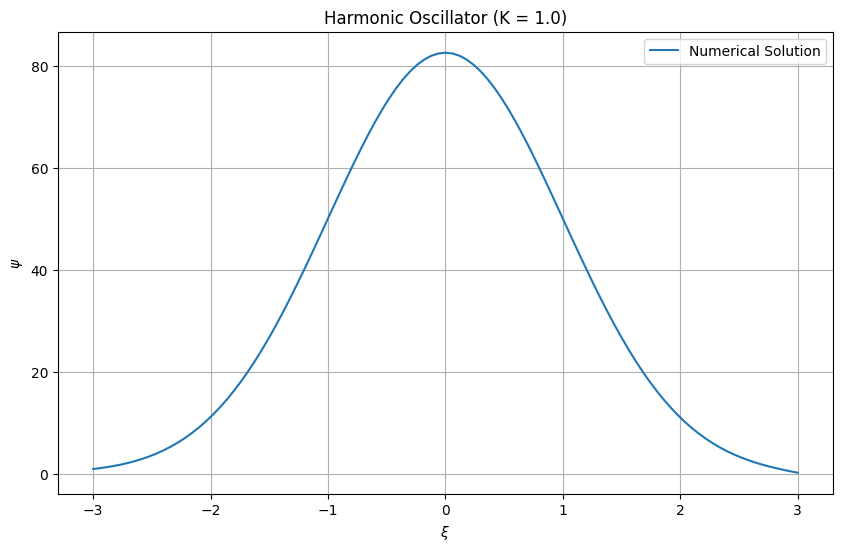

In [ ]:
# Creating the object
ho = harmonic_oscillator()

# Initial guess
psi_guess = 1.5

# k state (ground state)
k = 1

# Optimization
sol = ho.optimize(psi_guess, k)

# Plotting
ho.plot_results(sol)

In [177]:
print('The ground state energy is:', ho.min_k)

The ground state energy is: 1.0



**(d)** Make a few illustrative panels showing plots of the wave function for different values of $K$ as it converges to the solution. What does the tail of the wave function does when the values are slightly above or below the correct solution?


In [178]:
sol_1 = solve_ivp(func, [xi_i, xi_f], np.asarray([psi_0, opt_res], dtype = object),\
                    method='RK45', t_eval = xi_axis, args = (k_values[8],))

sol_2 = solve_ivp(func, [xi_i, xi_f], np.asarray([psi_0, opt_res], dtype = object),\
                    method='RK45', t_eval = xi_axis, args = (k_values[9],))

sol_3 = solve_ivp(func, [xi_i, xi_f], np.asarray([psi_0, opt_res], dtype = object),\
                    method='RK45', t_eval = xi_axis, args = (k_values[10],))

sol_4 = solve_ivp(func, [xi_i, xi_f], np.asarray([psi_0, opt_res], dtype = object),\
                    method='RK45', t_eval = xi_axis, args = (k_values[11],))

sol_5 = solve_ivp(func, [xi_i, xi_f], np.asarray([psi_0, opt_res], dtype = object),\
                    method='RK45', t_eval = xi_axis, args = (k_values[12],))

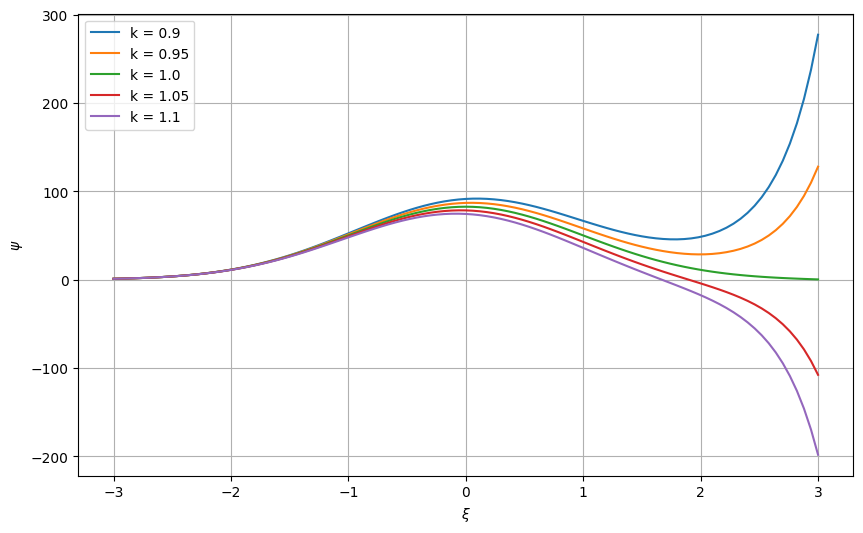

In [179]:
# plotting

plt.figure(figsize=(10,6))

plt.plot(sol_1.t, sol_1.y[0], label = f'k = {k_values[8]}')
plt.plot(sol_2.t, sol_2.y[0], label = f'k = {k_values[9]}')
plt.plot(sol_3.t, sol_3.y[0], label = f'k = {k_values[10]}')
plt.plot(sol_4.t, sol_4.y[0], label = f'k = {k_values[11]}')
plt.plot(sol_5.t, sol_5.y[0], label = f'k = {k_values[12]}')

plt.xlabel(r'$\xi$')
plt.ylabel(r'$\psi$')
plt.grid()
plt.legend()
plt.show()



**(e)** Find the **first four excited state energies** (to six significant digits) for the harmonic oscillator, using **the shooting method**. For the first (and third) excited state you will need to set $\psi(0) = 0$, $\psi'(0) = 1$).



**(f)** Make a few illustrative panels showing plots of the wave functions for different values of $K$ as they converge to their respective solutions.



**(g)** Make a single plot showing the **harmonic potential** joinly with the **energy ladder** of the quantum harmonic oscillator (include the ground state plus the first four excited states that you calculated above, each with their **respective wave functions**). Consider the particle to be an electron and choose appropriate units for any physical parameters you may need.